In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

file_path = '/content/drive/MyDrive/Colab Notebooks/Job_Tweets.csv'
df = pd.read_csv(file_path)

In [3]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 57.6 MB/s eta 0:00:00


In [4]:
#IMPORTS HERE
import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt
from collections import Counter
import plotly.express as px
from wordcloud import WordCloud
from geopy.geocoders import Nominatim
import logging
from geopy.exc import GeocoderTimedOut
from textblob import TextBlob
import gensim
from gensim import corpora
from gensim.models.ldamodel import LdaModel

In [5]:
# Download required nltk resources
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [6]:
# Function to clean the text
def clean_text(text):
   text = re.sub(r'http\S+', '', text) # Remove URLs
   text = re.sub(r'@\w+', '', text) # Remove mentions
   text = re.sub(r'#\w+', '', text) # Remove hashtags
   text = re.sub(r'\d+', '', text) # Remove numbers
   text = re.sub(r'[^\w\s]', '', text) # Remove punctuation
   text = text.lower() # Convert to lowercase
   return text

In [7]:
# Apply cleaning
df['Clean_Text'] = df['Text'].apply(clean_text)
from nltk.corpus import stopwords

In [8]:
import warnings
warnings.filterwarnings("ignore")

In [9]:
# Define stopwords and custom stopwords
stop_words = set(stopwords.words('english'))
custom_stopwords = ['hiring', 'job', 'amp', 'big', 'best', 'come', 'would', 'like',
                    'find', 'need', 'people', 'currently', 'company', 'learn', 'way', 'opportunity',
                    'team', 'detail', 'link', 'click', 'visit', 'information', 'new', 'location',
                    'join', 'u', 'today', 'join', 'position', 'full', 'send', 'description', 'experience',
                    'please', 'cv', 'hiring', 'job', 'apply', 'looking', 'position', 'candidate',
                    'role', 'vacancy', 'work','want','one','website','per','hour','help','please','following',
                  'link',
                   'us',' amp ','job opportunity','required','today','perform','job description','looking','new',
                    'dedicated','ltgt','hiredinny']
stop_words.update([word.lower() for word in custom_stopwords])

In [10]:
# Tokenize and remove stopwords
df['Tokens'] = df['Clean_Text'].apply(lambda x: [word for word in x.split() if word not in stop_words])
from nltk.stem import WordNetLemmatizer

In [11]:
lemmatizer = WordNetLemmatizer()

In [12]:
# Lemmatize tokens
df['Lemmatized_Tokens'] = df['Tokens'].apply(lambda tokens: [lemmatizer.lemmatize(token) for token in tokens])
# Function to clean tokens and remove stopwords after lemmatization
def clean_and_filter(tokens):
   return [word for word in tokens if word.lower() not in stop_words]

In [13]:
# Apply the function to lemmatized tokens
df['Cleaned_Lemmatized_Tokens'] = df['Lemmatized_Tokens'].apply(clean_and_filter)
# Combine all cleaned and lemmatized text for word cloud
text_combined = ' '.join(df['Cleaned_Lemmatized_Tokens'].apply(lambda x: ' '.join(x)))

In [14]:
# Generate first word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_combined)

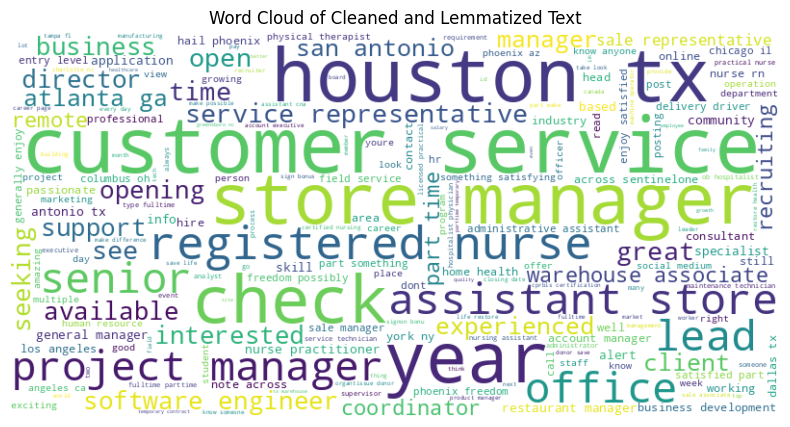

In [15]:
# Display word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Cleaned and Lemmatized Text')
plt.show()

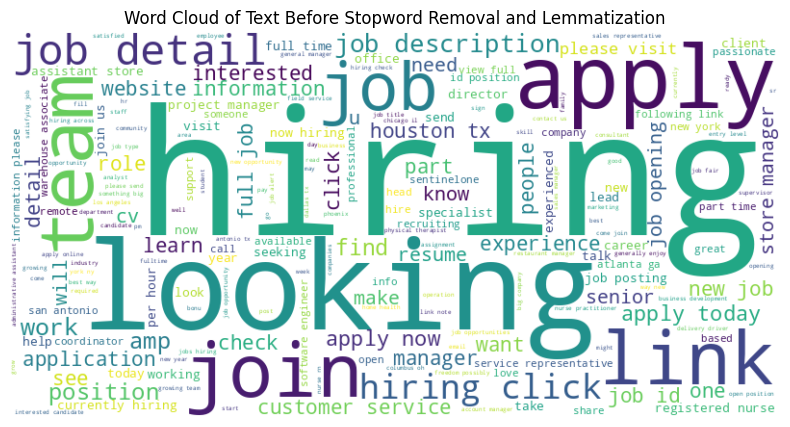

In [16]:
text_before_lemmatization = ' '.join(df['Clean_Text'])
wordcloud_before = WordCloud(width=800, height=400, background_color='white').generate(text_before_lemmatization)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_before, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Text Before Stopword Removal and Lemmatization')
plt.show()

In [17]:
df.columns

Index(['ID', 'Timestamp', 'User', 'Text', 'Hashtag', 'Retweets', 'Likes',
       'Replies', 'Source', 'Location', 'Verified_Account', 'Followers',
       'Following', 'Clean_Text', 'Tokens', 'Lemmatized_Tokens',
       'Cleaned_Lemmatized_Tokens'],
      dtype='object')

In [18]:
# Define refined finance keywords
finance_keywords = [
    'finance', 'financial', 'accounting', 'accountant', 'analyst',
    'financial analyst', 'banking', 'bank', 'investment',
    'investment analyst', 'asset management', 'portfolio',
    'cpa', 'audit', 'auditor', 'tax', 'treasury', 'risk', 'credit',
    'loan officer', 'underwriter', 'controller', 'bookkeeper',

    # Added keywords (expanded coverage)
    'finance associate', 'financial services', 'corporate finance',
    'financial planning', 'budgeting', 'forecasting', 'business analyst',
    'financial modeling',
    'wealth management', 'private equity', 'hedge fund',
    'trading', 'capital markets', 'equity research'
]

# Create regex pattern
pattern = r'\b(' + '|'.join(finance_keywords) + r')\b'

# Apply finance filter
df_finance = df[df['Clean_Text'].str.contains(pattern, case=False, na=False)]

# Count remaining tweets
print("Number of tweets after finance filter:", len(df_finance))

# Preview results
df_finance.head()

Number of tweets after finance filter: 2844


,ID,Timestamp,User,Text,Hashtag,Retweets,Likes,Replies,Source,Location,Verified_Account,Followers,Following,Clean_Text,Tokens,Lemmatized_Tokens,Cleaned_Lemmatized_Tokens
20,1211778000271953921,2019-12-30 22:36:03+00:00,Myticas,We are #hiring Security Network Business Analy...,"['hiring', 'jobs', 'Ottawa']",0,0,0,"<a href=""http://www.ziprecruiter.com"" rel=""nof...","Ottawa, Ontario",False,3157,4543,we are security network business analyst in o...,"[security, network, business, analyst, ottawa]","[security, network, business, analyst, ottawa]","[security, network, business, analyst, ottawa]"
26,1211777983188525058,2019-12-30 22:35:59+00:00,Myticas,"We are #hiring Business Analyst in Ottawa, ON ...","['hiring', 'jobs', 'Ottawa']",0,0,0,"<a href=""http://www.ziprecruiter.com"" rel=""nof...","Ottawa, Ontario",False,3157,4543,we are business analyst in ottawa on,"[business, analyst, ottawa]","[business, analyst, ottawa]","[business, analyst, ottawa]"
54,1211777809493954565,2019-12-30 22:35:18+00:00,AjuliaCareers,We are #hiring Director Financial Reporting in...,"['hiring', 'jobs', 'OverlandPark']",0,0,0,"<a href=""http://www.ziprecruiter.com"" rel=""nof...",United States,False,225,137,we are director financial reporting in overla...,"[director, financial, reporting, overland, par...","[director, financial, reporting, overland, par...","[director, financial, reporting, overland, par..."
84,1211774502910214145,2019-12-30 22:22:09+00:00,ATSolutionsInc,We are #hiring Server Administrator/IT Analyst...,"['hiring', 'jobs', 'Louisville']",0,0,0,"<a href=""http://www.ziprecruiter.com"" rel=""nof...",New Jersey,False,611,1940,we are server administratorit analyst in lou...,"[server, administratorit, analyst, louisville,...","[server, administratorit, analyst, louisville,...","[server, administratorit, analyst, louisville,..."
106,1211764053741309954,2019-12-30 21:40:38+00:00,lpcpersonnel,We are #hiring Financial Officer in Real Estat...,"['hiring', 'jobs', 'Houston']",0,0,0,"<a href=""http://www.ziprecruiter.com"" rel=""nof...","Houston, TX 77007",False,785,2239,we are financial officer in real estate ltgt ...,"[financial, officer, real, estate, houston, tx]","[financial, officer, real, estate, houston, tx]","[financial, officer, real, estate, houston, tx]"


In [19]:
# Step 1: Import regex if not already imported
import re

# Step 2: Define mappings

# State abbreviations → full state names (expanded)
state_abbrev = {
    'ma': 'Massachusetts',
    'il': 'Illinois',
    'ny': 'New York',
    'ca': 'California',
    'tx': 'Texas',
    'fl': 'Florida',
    'nc': 'North Carolina',
    'nj': 'New Jersey'
}

# City → state mappings (expanded finance hubs)
city_to_state = {
    # Massachusetts
    'boston': 'Massachusetts',

    # Illinois
    'chicago': 'Illinois',

    # New York
    'new york': 'New York',
    'nyc': 'New York',

    # California
    'los angeles': 'California',
    'san francisco': 'California',
    'san diego': 'California',

    # Texas
    'houston': 'Texas',
    'dallas': 'Texas',
    'austin': 'Texas',

    # Florida (Miami finance hub)
    'miami': 'Florida',

    # North Carolina (Charlotte banking hub)
    'charlotte': 'North Carolina',

    # New Jersey (often tied to NYC finance roles)
    'newark': 'New Jersey',
    'jersey city': 'New Jersey'
}

# Step 3: Function to extract state from tweet text
def extract_state(text):
    text = text.lower()

    # Check for city names first
    for city, state in city_to_state.items():
        if city in text:
            return state

    # Check for state abbreviations (word boundaries)
    for abbrev, state in state_abbrev.items():
        if re.search(r'\b' + abbrev + r'\b', text):
            return state

    # Check for full state names
    for state in state_abbrev.values():
        if state.lower() in text:
            return state

    # If no match found
    return None

# Step 4: Apply function to your finance-filtered dataset
df_finance['Standardized_Location'] = df_finance['Clean_Text'].apply(extract_state)

# Step 5: View distribution of extracted locations
df_finance['Standardized_Location'].value_counts()

,count
Standardized_Location,
California,223
Texas,185
North Carolina,160
New York,60
Illinois,58
Florida,48
Massachusetts,46
New Jersey,35


In [20]:
df_finance['Standardized_Location'] = df_finance['Clean_Text'].apply(extract_state)

In [21]:
df_finance.head()

,ID,Timestamp,User,Text,Hashtag,Retweets,Likes,Replies,Source,Location,Verified_Account,Followers,Following,Clean_Text,Tokens,Lemmatized_Tokens,Cleaned_Lemmatized_Tokens,Standardized_Location
20,1211778000271953921,2019-12-30 22:36:03+00:00,Myticas,We are #hiring Security Network Business Analy...,"['hiring', 'jobs', 'Ottawa']",0,0,0,"<a href=""http://www.ziprecruiter.com"" rel=""nof...","Ottawa, Ontario",False,3157,4543,we are security network business analyst in o...,"[security, network, business, analyst, ottawa]","[security, network, business, analyst, ottawa]","[security, network, business, analyst, ottawa]",None
26,1211777983188525058,2019-12-30 22:35:59+00:00,Myticas,"We are #hiring Business Analyst in Ottawa, ON ...","['hiring', 'jobs', 'Ottawa']",0,0,0,"<a href=""http://www.ziprecruiter.com"" rel=""nof...","Ottawa, Ontario",False,3157,4543,we are business analyst in ottawa on,"[business, analyst, ottawa]","[business, analyst, ottawa]","[business, analyst, ottawa]",None
54,1211777809493954565,2019-12-30 22:35:18+00:00,AjuliaCareers,We are #hiring Director Financial Reporting in...,"['hiring', 'jobs', 'OverlandPark']",0,0,0,"<a href=""http://www.ziprecruiter.com"" rel=""nof...",United States,False,225,137,we are director financial reporting in overla...,"[director, financial, reporting, overland, par...","[director, financial, reporting, overland, par...","[director, financial, reporting, overland, par...",None
84,1211774502910214145,2019-12-30 22:22:09+00:00,ATSolutionsInc,We are #hiring Server Administrator/IT Analyst...,"['hiring', 'jobs', 'Louisville']",0,0,0,"<a href=""http://www.ziprecruiter.com"" rel=""nof...",New Jersey,False,611,1940,we are server administratorit analyst in lou...,"[server, administratorit, analyst, louisville,...","[server, administratorit, analyst, louisville,...","[server, administratorit, analyst, louisville,...",None
106,1211764053741309954,2019-12-30 21:40:38+00:00,lpcpersonnel,We are #hiring Financial Officer in Real Estat...,"['hiring', 'jobs', 'Houston']",0,0,0,"<a href=""http://www.ziprecruiter.com"" rel=""nof...","Houston, TX 77007",False,785,2239,we are financial officer in real estate ltgt ...,"[financial, officer, real, estate, houston, tx]","[financial, officer, real, estate, houston, tx]","[financial, officer, real, estate, houston, tx]",Texas


In [22]:
major_finance_states = [
    'Massachusetts',
    'Illinois',
    'New York',
    'California',
    'Texas',
    'Florida',
    'North Carolina',
    'New Jersey'
]

df_finance_major = df_finance[
    df_finance['Standardized_Location'].isin(major_finance_states)
]

print("Total finance tweets:", len(df_finance))
print("Tweets in major finance states:", len(df_finance_major))

df_finance_major['Standardized_Location'].value_counts()

Total finance tweets: 2844
Tweets in major finance states: 815


,count
Standardized_Location,
California,223
Texas,185
North Carolina,160
New York,60
Illinois,58
Florida,48
Massachusetts,46
New Jersey,35


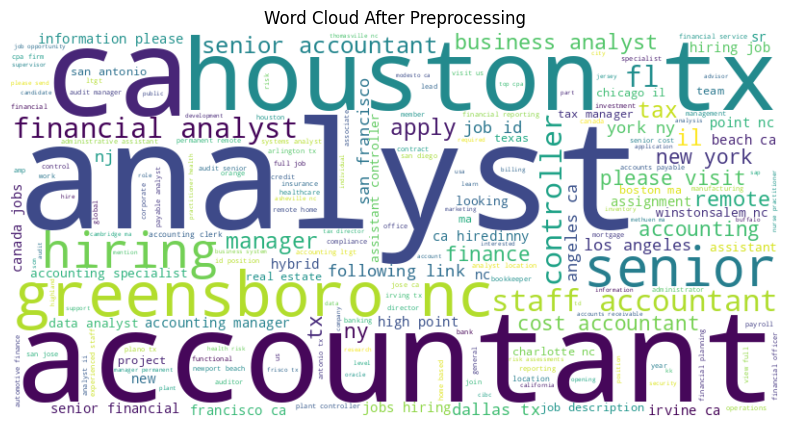

In [23]:
# Step 1: Import libraries
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Step 2: Combine all cleaned text into one large string
text = " ".join(df_finance_major['Clean_Text'].dropna())

# Step 3: Generate the word cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=200
).generate(text)

# Step 4: Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud After Preprocessing')
plt.show()

In [24]:
import plotly.express as px
from collections import Counter

# Flatten tokens
all_tokens = [word for tokens in df_finance_major['Cleaned_Lemmatized_Tokens'] for word in tokens]

# Count frequencies
word_counts = Counter(all_tokens)

# Top N
top_n = 20
most_common = word_counts.most_common(top_n)

words, counts = zip(*most_common)

# Create DataFrame for Plotly
import pandas as pd
df_plot = pd.DataFrame({'Term': words, 'Frequency': counts})

# Plot
fig = px.bar(df_plot, x='Term', y='Frequency', title='Top 20 Most Frequent Terms')
fig.update_layout(xaxis_tickangle=-45)
fig.show()

In [25]:
from nltk.util import ngrams

# Generate bigrams
bigrams = []
for tokens in df_finance_major['Cleaned_Lemmatized_Tokens']:
    bigrams.extend(list(ngrams(tokens, 2)))

# Count
bigram_counts = Counter(bigrams)

# Top N
top_n = 15
most_common_bigrams = bigram_counts.most_common(top_n)

# Format
bigram_labels = [' '.join(bigram) for bigram, count in most_common_bigrams]
bigram_values = [count for bigram, count in most_common_bigrams]

# DataFrame
df_bigrams = pd.DataFrame({'Bigram': bigram_labels, 'Frequency': bigram_values})

# Plot
fig = px.bar(df_bigrams, x='Bigram', y='Frequency', title='Top Bigrams')
fig.update_layout(xaxis_tickangle=-45)
fig.show()

In [26]:
# Generate trigrams
trigrams = []
for tokens in df_finance_major['Cleaned_Lemmatized_Tokens']:
    trigrams.extend(list(ngrams(tokens, 3)))

# Count
trigram_counts = Counter(trigrams)

# Top N
top_n = 15
most_common_trigrams = trigram_counts.most_common(top_n)

# Format
trigram_labels = [' '.join(trigram) for trigram, count in most_common_trigrams]
trigram_values = [count for trigram, count in most_common_trigrams]

# DataFrame
df_trigrams = pd.DataFrame({'Trigram': trigram_labels, 'Frequency': trigram_values})

# Plot
fig = px.bar(df_trigrams, x='Trigram', y='Frequency', title='Top Trigrams')
fig.update_layout(xaxis_tickangle=-45)
fig.show()

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF vectorizer
vectorizer = TfidfVectorizer(stop_words='english')

# Fit and transform the cleaned text from df_finance_major (before deduplication)
tfidf_matrix = vectorizer.fit_transform(df_finance_major['Clean_Text'])

print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (815, 1036)


In [28]:
from sklearn.metrics.pairwise import cosine_similarity

# Compute cosine similarity matrix
cosine_sim = cosine_similarity(tfidf_matrix)

print("Cosine similarity matrix shape:", cosine_sim.shape)

Cosine similarity matrix shape: (815, 815)


In [29]:
import numpy as np

threshold = 0.95
to_remove = set()

n = cosine_sim.shape[0]

for i in range(n):
    for j in range(i + 1, n):
        if cosine_sim[i, j] >= threshold:
            to_remove.add(j)

# Keep only non-duplicate indices
keep_indices = [i for i in range(n) if i not in to_remove]

# Create deduplicated dataset
df_dedup = df_finance_major.iloc[keep_indices].reset_index(drop=True)

print("Original tweets:", len(df_finance_major))
print("After deduplication:", len(df_dedup))

Original tweets: 815
After deduplication: 604


In [30]:
df_final = df_dedup

In [31]:
texts = df_final['Tokens']

In [32]:
from gensim import corpora

# Create dictionary from existing tokens
dictionary = corpora.Dictionary(texts)

# Optional: filter extremes to improve topic quality
dictionary.filter_extremes(no_below=5, no_above=0.5)

# Create corpus (bag-of-words)
corpus = [dictionary.doc2bow(text) for text in texts]

print("Number of unique tokens:", len(dictionary))
print("Corpus size:", len(corpus))

Number of unique tokens: 137
Corpus size: 604


In [33]:
from gensim.models import LdaModel, CoherenceModel

coherence_scores = []
topic_range = range(2, 11)

for k in topic_range:
    lda_model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        random_state=42,
        passes=10
    )

    coherence_model = CoherenceModel(
        model=lda_model,
        texts=texts,
        dictionary=dictionary,
        coherence='c_v'
    )

    coherence_scores.append(coherence_model.get_coherence())

coherence_df = list(zip(topic_range, coherence_scores))
coherence_df

[(2, np.float64(0.4167316068119332)),
 (3, np.float64(0.39648307753466666)),
 (4, np.float64(0.40399790026562943)),
 (5, np.float64(0.4320751010111755)),
 (6, np.float64(0.41602488398372534)),
 (7, np.float64(0.43570414127799256)),
 (8, np.float64(0.4368777092206738)),
 (9, np.float64(0.4114231972036586)),
 (10, np.float64(0.41513299565601935))]

In [34]:
import plotly.express as px
import pandas as pd

coherence_plot_df = pd.DataFrame(coherence_df, columns=['num_topics', 'coherence'])

fig = px.line(coherence_plot_df, x='num_topics', y='coherence',
              title='Coherence Score by Number of Topics')
fig.show()

In [35]:
optimal_k = 8  # change based on coherence results

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=optimal_k,
    random_state=42,
    passes=10
)

In [36]:
topics = lda_model.print_topics(num_words=10)
for topic in topics:
    print(topic)

(0, '0.103*"manager" + 0.087*"finance" + 0.078*"tax" + 0.078*"ca" + 0.076*"accounting" + 0.057*"remote" + 0.042*"tx" + 0.036*"based" + 0.032*"fl" + 0.031*"permanent"')
(1, '0.147*"accountant" + 0.133*"ny" + 0.087*"cost" + 0.086*"york" + 0.036*"senior" + 0.034*"estate" + 0.033*"il" + 0.032*"plant" + 0.030*"real" + 0.026*"charlotte"')
(2, '0.131*"tx" + 0.086*"ca" + 0.078*"accountant" + 0.064*"houston" + 0.057*"analyst" + 0.053*"jobs" + 0.052*"canada" + 0.046*"financial" + 0.044*"dallas" + 0.029*"senior"')
(3, '0.115*"controller" + 0.086*"accounting" + 0.084*"assistant" + 0.068*"il" + 0.058*"tx" + 0.048*"ca" + 0.041*"cpa" + 0.039*"manager" + 0.036*"chicago" + 0.035*"houston"')
(4, '0.109*"ca" + 0.066*"analyst" + 0.053*"audit" + 0.046*"beach" + 0.038*"manager" + 0.038*"los" + 0.038*"angeles" + 0.036*"financial" + 0.030*"compliance" + 0.030*"data"')
(5, '0.201*"analyst" + 0.078*"business" + 0.072*"ca" + 0.053*"id" + 0.047*"san" + 0.039*"francisco" + 0.039*"nj" + 0.031*"financial" + 0.030*"t

In [37]:
# Display the LDA model summary
print("LDA Model Summary:\n")
print(lda_model)

# Display topics in a readable format
print("\nTopics:\n")
for i in range(optimal_k):
    print(f"Topic {i}:")
    print(lda_model.show_topic(i, topn=10))
    print()

# Create a DataFrame of topics for reporting
topics_data = []

for topic_id in range(optimal_k):
    for word, weight in lda_model.show_topic(topic_id, topn=10):
        topics_data.append([topic_id, word, weight])

topics_df = pd.DataFrame(topics_data, columns=['Topic', 'Word', 'Weight'])

# Show a preview of the topics table
topics_df.head(20)

LDA Model Summary:

LdaModel<num_terms=137, num_topics=8, decay=0.5, chunksize=2000>

Topics:

Topic 0:
[('manager', np.float32(0.10271944)), ('finance', np.float32(0.08655146)), ('tax', np.float32(0.078089915)), ('ca', np.float32(0.0779038)), ('accounting', np.float32(0.07644618)), ('remote', np.float32(0.05660124)), ('tx', np.float32(0.041649543)), ('based', np.float32(0.035849113)), ('fl', np.float32(0.031634595)), ('permanent', np.float32(0.031049885))]

Topic 1:
[('accountant', np.float32(0.1465942)), ('ny', np.float32(0.13250029)), ('cost', np.float32(0.08735153)), ('york', np.float32(0.0855029)), ('senior', np.float32(0.036364328)), ('estate', np.float32(0.033564255)), ('il', np.float32(0.032777492)), ('plant', np.float32(0.032323267)), ('real', np.float32(0.029763892)), ('charlotte', np.float32(0.026399177))]

Topic 2:
[('tx', np.float32(0.13063706)), ('ca', np.float32(0.08565249)), ('accountant', np.float32(0.07782695)), ('houston', np.float32(0.06412255)), ('analyst', np.floa

,Topic,Word,Weight
0,0,manager,0.102719
1,0,finance,0.086551
2,0,tax,0.078090
3,0,ca,0.077904
4,0,accounting,0.076446
5,0,remote,0.056601
6,0,tx,0.041650
7,0,based,0.035849
8,0,fl,0.031635
9,0,permanent,0.031050


In [38]:
import plotly.graph_objects as go
import numpy as np

# -----------------------------
# 1. Prepare topic data
# -----------------------------
topics = []
topic_sizes = []

for topic_id in range(optimal_k):
    topic_words = lda_model.show_topic(topic_id, topn=10)
    topics.append(topic_words)

    # Topic "size" = sum of word weights
    topic_sizes.append(sum([weight for _, weight in topic_words]))

# Normalize sizes for visualization
topic_sizes = np.array(topic_sizes)
topic_sizes = topic_sizes / topic_sizes.max() * 50  # scale bubbles

# Create random 2D positions for bubbles (for layout)
np.random.seed(42)
x = np.random.rand(optimal_k)
y = np.random.rand(optimal_k)

# -----------------------------
# 2. Create bubble chart
# -----------------------------
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=x,
    y=y,
    mode='markers+text',
    marker=dict(
        size=topic_sizes,
    ),
    text=[f"Topic {i}" for i in range(optimal_k)],
    textposition="middle center",
    customdata=list(range(optimal_k)),
    hovertemplate="Topic %{customdata}<extra></extra>"
))

# -----------------------------
# 3. Slider (relevance control)
# -----------------------------
slider_steps = []

for rel in np.linspace(0, 1, 6):
    # For each relevance level, recompute displayed word importance
    annotations = []

    for topic_id in range(optimal_k):
        words = topics[topic_id]

        # Adjust word weights by relevance factor
        adjusted_words = [
            (word, weight * (1 - rel) + rel)
            for word, weight in words
        ]

        top_words = sorted(adjusted_words, key=lambda x: x[1], reverse=True)[:5]
        word_text = "<br>".join([f"{w[0]}" for w in top_words])

        annotations.append(dict(
            x=x[topic_id],
            y=y[topic_id],
            text=f"Topic {topic_id}<br>{word_text}",
            showarrow=False,
            font=dict(size=10)
        ))

    slider_steps.append(dict(
        method="update",
        args=[{"annotations": [annotations]}],
        label=str(round(rel, 2))
    ))

# -----------------------------
# 4. Layout
# -----------------------------
fig.update_layout(
    title="LDA Topic Visualization (Bubble Chart)",
    showlegend=False,
    updatemenus=[],
    sliders=[{
        "steps": slider_steps,
        "currentvalue": {"prefix": "Relevance: "}
    }]
)

fig.show()

In [39]:
!pip install dash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 48.8 MB/s eta 0:00:00


In [40]:
import plotly.graph_objects as go
import numpy as np
import ipywidgets as widgets
from IPython.display import display

# -----------------------------
# Prepare topic data
# -----------------------------
topics = []
topic_sizes = []

for topic_id in range(optimal_k):
    topic_words = lda_model.show_topic(topic_id, topn=10)
    topics.append(topic_words)
    topic_sizes.append(sum([weight for _, weight in topic_words]))

topic_sizes = np.array(topic_sizes)
topic_sizes = topic_sizes / topic_sizes.max() * 50

np.random.seed(42)
x = np.random.rand(optimal_k)
y = np.random.rand(optimal_k)

# -----------------------------
# Bubble chart
# -----------------------------
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=x,
    y=y,
    mode='markers+text',
    marker=dict(size=topic_sizes),
    text=[f"Topic {i}" for i in range(optimal_k)],
    textposition="middle center",
    hovertemplate="Topic %{text}<extra></extra>"
))

fig.update_layout(
    title="LDA Topic Visualization",
    showlegend=False
)

# -----------------------------
# Dropdown for topic selection
# -----------------------------
dropdown = widgets.Dropdown(
    options=[(f"Topic {i}", i) for i in range(optimal_k)],
    description='Select Topic:'
)

output = widgets.Output()

def display_topic(change):
    output.clear_output()
    topic_id = change['new']
    words = lda_model.show_topic(topic_id, topn=10)

    with output:
        print(f"Topic {topic_id}\n")
        for word, weight in words:
            print(f"{word} ({weight:.3f})")

dropdown.observe(display_topic, names='value')

# Initialize display
display_topic({'new': 0})

# -----------------------------
# Layout
# -----------------------------
display(fig)
display(dropdown)
display(output)

Dropdown(description='Select Topic:', options=(('Topic 0', 0), ('Topic 1', 1), ('Topic 2', 2), ('Topic 3', 3),…

Output()

In [41]:
import plotly.graph_objects as go

for topic_id in range(optimal_k):
    words = lda_model.show_topic(topic_id, topn=10)

    word_labels = [w[0] for w in words]
    word_scores = [w[1] for w in words]

    fig = go.Figure(data=[go.Bar(x=word_labels, y=word_scores)])

    fig.update_layout(
        title=f"Topic {topic_id} Top Keywords",
        xaxis_title="Words",
        yaxis_title="Weight"
    )

    fig.show()

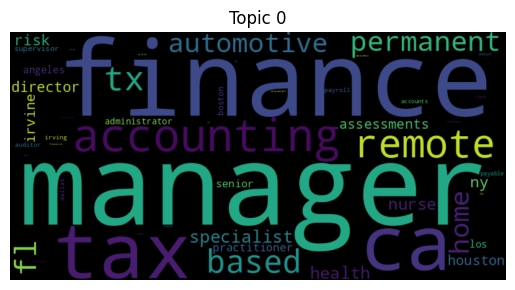

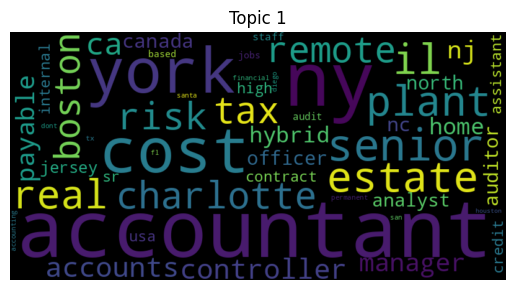

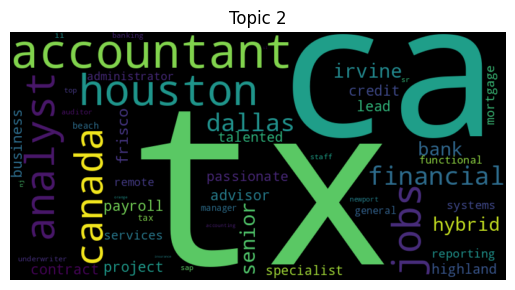

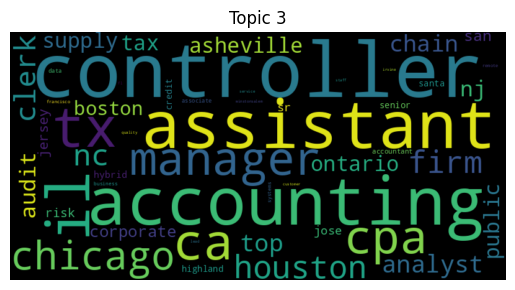

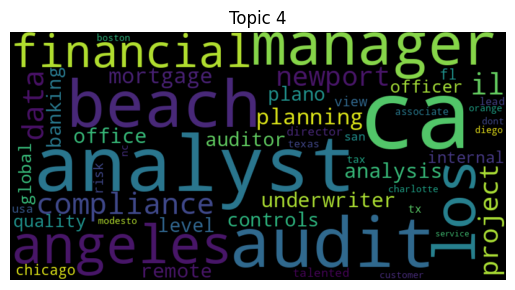

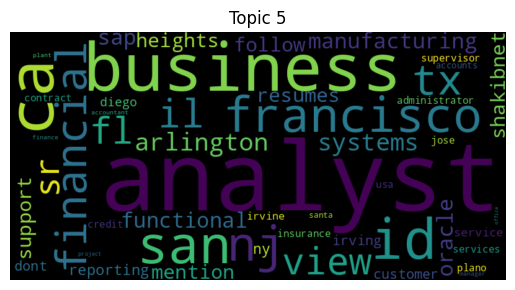

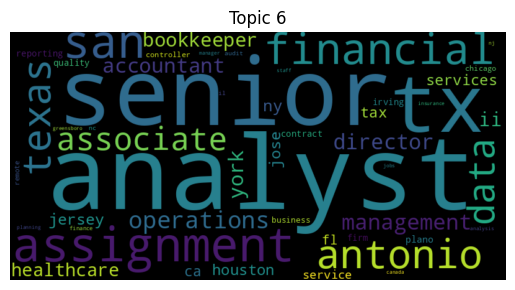

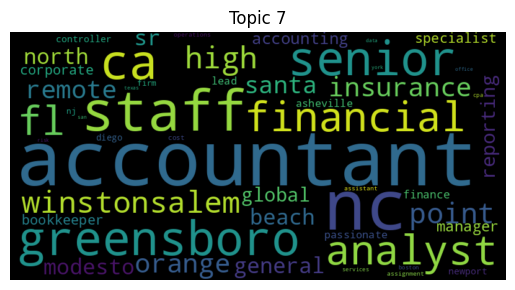

In [42]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

for topic_id in range(optimal_k):
    words = dict(lda_model.show_topic(topic_id, topn=50))

    wordcloud = WordCloud(width=800, height=400).generate_from_frequencies(words)

    plt.figure()
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Topic {topic_id}")
    plt.show()

In [43]:
# Define the target region (Kentucky + surrounding states), IGNORE THIS CODE
target_states = [
    'Kentucky', 'Tennessee', 'Ohio', 'Indiana',
    'Illinois', 'West Virginia', 'Virginia', 'Missouri'
]

# Filter dataset
df_region = df_finance[df_finance['Standardized_Location'].isin(target_states)]

# Check results
print("Tweets after regional filter:", len(df_region))

# Preview
df_region.head()

Tweets after regional filter: 58


,ID,Timestamp,User,Text,Hashtag,Retweets,Likes,Replies,Source,Location,Verified_Account,Followers,Following,Clean_Text,Tokens,Lemmatized_Tokens,Cleaned_Lemmatized_Tokens,Standardized_Location
1147,1210626369367003137,2019-12-27 18:19:53+00:00,OneEliteStaff,We are #hiring Sr. Systems Analyst - Salesforc...,"['hiring', 'jobs', 'Chicago']",0,1,0,"<a href=""http://www.ziprecruiter.com"" rel=""nof...","Dallas, TX",False,5,199,we are sr systems analyst salesforce in chic...,"[sr, systems, analyst, salesforce, chicago, il]","[sr, system, analyst, salesforce, chicago, il]","[sr, system, analyst, salesforce, chicago, il]",Illinois
1848,1210226831615545345,2019-12-26 15:52:16+00:00,birkstaffinginc,We are #hiring Quality Assurance Analyst in Mo...,"['hiring', 'jobs', 'MountProspect']",0,0,0,"<a href=""http://www.ziprecruiter.com"" rel=""nof...","Park Ridge, IL",False,125,302,we are quality assurance analyst in mount pro...,"[quality, assurance, analyst, mount, prospect,...","[quality, assurance, analyst, mount, prospect,...","[quality, assurance, analyst, mount, prospect,...",Illinois
3922,1207882125879455745,2019-12-20 04:35:14+00:00,cameroncraig,"We are #hiring Audit Manager in Chicago, IL ht...","['hiring', 'jobs', 'Chicago']",0,0,0,"<a href=""http://www.ziprecruiter.com"" rel=""nof...",USA,False,23465,24758,we are audit manager in chicago il,"[audit, manager, chicago, il]","[audit, manager, chicago, il]","[audit, manager, chicago, il]",Illinois
5815,1206954760521363457,2019-12-17 15:10:13+00:00,AllLinesTech,We are #hiring Desktop Support Analyst in Cham...,"['hiring', 'jobs', 'Champaign']",0,1,0,"<a href=""http://www.ziprecruiter.com"" rel=""nof...",NaN,False,124,60,we are desktop support analyst in champaign i...,"[desktop, support, analyst, champaign, il]","[desktop, support, analyst, champaign, il]","[desktop, support, analyst, champaign, il]",Illinois
8121,1205175292848934914,2019-12-12 17:19:15+00:00,EspoCorp,We are #hiring ServiceNow Business Analyst / S...,"['hiring', 'jobs', 'Chicago']",0,0,0,"<a href=""http://www.ziprecruiter.com"" rel=""nof...","Chicago, IL & Suburbs",False,384,516,we are servicenow business analyst systems a...,"[servicenow, business, analyst, systems, analy...","[servicenow, business, analyst, system, analys...","[servicenow, business, analyst, system, analys...",Illinois


In [44]:
# Define entry-level keywords
entry_level_keywords = [
    'entry level', 'entry-level', 'junior', 'jr',
    'new grad', 'new graduate', 'graduate program', 'grad program',
    'early career', 'no experience', '0-1 years', '0-2 years',
    'internship', 'intern'
]

# Function to check if a tweet contains any entry-level keyword
def is_entry_level(text):
    text = text.lower()
    return any(keyword in text for keyword in entry_level_keywords)

# Apply to the original tweet text (better than tokens for phrase matching)
df_region['Is_Entry_Level'] = df_region['Text'].apply(is_entry_level)

# Preview results
df_region[['Text', 'Is_Entry_Level']].head()

,Text,Is_Entry_Level
1147,We are #hiring Sr. Systems Analyst - Salesforc...,False
1848,We are #hiring Quality Assurance Analyst in Mo...,False
3922,"We are #hiring Audit Manager in Chicago, IL ht...",False
5815,We are #hiring Desktop Support Analyst in Cham...,False
8121,We are #hiring ServiceNow Business Analyst / S...,False


In [45]:
df_region['Is_Entry_Level'].value_counts()

,count
Is_Entry_Level,
False,54
True,4


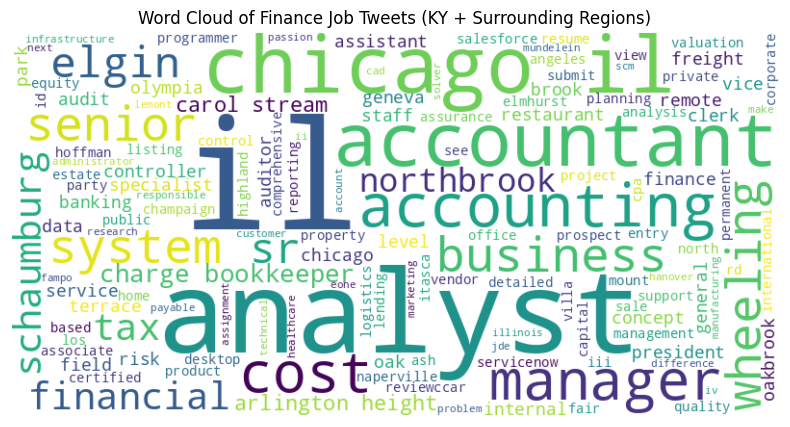

In [46]:
# Combine all tokens into a single string, IGNORE
text_combined_region = ' '.join(
    df_region['Cleaned_Lemmatized_Tokens'].apply(lambda x: ' '.join(x))
)

# Generate the word cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text_combined_region)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Finance Job Tweets (KY + Surrounding Regions)')
plt.show()

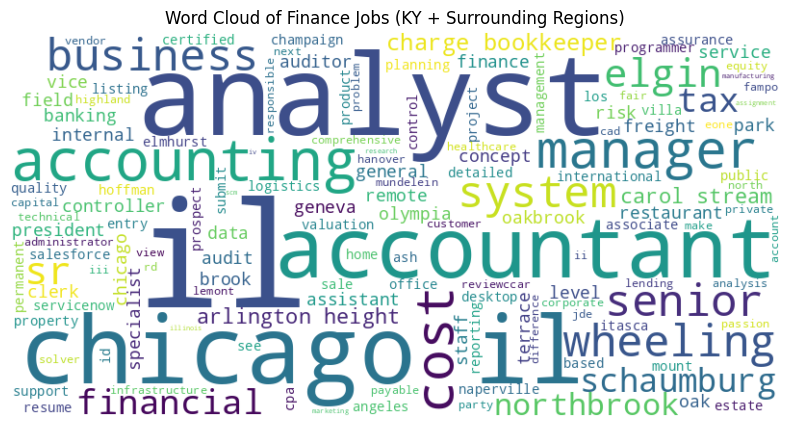

In [47]:
# Combine all cleaned + lemmatized tokens into one string, IGNORE
text_combined_region = ' '.join(
    df_region['Cleaned_Lemmatized_Tokens'].apply(lambda x: ' '.join(x))
)

# Generate the word cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text_combined_region)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Finance Jobs (KY + Surrounding Regions)')
plt.show()

In [48]:
df_region.head()

,ID,Timestamp,User,Text,Hashtag,Retweets,Likes,Replies,Source,Location,Verified_Account,Followers,Following,Clean_Text,Tokens,Lemmatized_Tokens,Cleaned_Lemmatized_Tokens,Standardized_Location,Is_Entry_Level
1147,1210626369367003137,2019-12-27 18:19:53+00:00,OneEliteStaff,We are #hiring Sr. Systems Analyst - Salesforc...,"['hiring', 'jobs', 'Chicago']",0,1,0,"<a href=""http://www.ziprecruiter.com"" rel=""nof...","Dallas, TX",False,5,199,we are sr systems analyst salesforce in chic...,"[sr, systems, analyst, salesforce, chicago, il]","[sr, system, analyst, salesforce, chicago, il]","[sr, system, analyst, salesforce, chicago, il]",Illinois,False
1848,1210226831615545345,2019-12-26 15:52:16+00:00,birkstaffinginc,We are #hiring Quality Assurance Analyst in Mo...,"['hiring', 'jobs', 'MountProspect']",0,0,0,"<a href=""http://www.ziprecruiter.com"" rel=""nof...","Park Ridge, IL",False,125,302,we are quality assurance analyst in mount pro...,"[quality, assurance, analyst, mount, prospect,...","[quality, assurance, analyst, mount, prospect,...","[quality, assurance, analyst, mount, prospect,...",Illinois,False
3922,1207882125879455745,2019-12-20 04:35:14+00:00,cameroncraig,"We are #hiring Audit Manager in Chicago, IL ht...","['hiring', 'jobs', 'Chicago']",0,0,0,"<a href=""http://www.ziprecruiter.com"" rel=""nof...",USA,False,23465,24758,we are audit manager in chicago il,"[audit, manager, chicago, il]","[audit, manager, chicago, il]","[audit, manager, chicago, il]",Illinois,False
5815,1206954760521363457,2019-12-17 15:10:13+00:00,AllLinesTech,We are #hiring Desktop Support Analyst in Cham...,"['hiring', 'jobs', 'Champaign']",0,1,0,"<a href=""http://www.ziprecruiter.com"" rel=""nof...",NaN,False,124,60,we are desktop support analyst in champaign i...,"[desktop, support, analyst, champaign, il]","[desktop, support, analyst, champaign, il]","[desktop, support, analyst, champaign, il]",Illinois,False
8121,1205175292848934914,2019-12-12 17:19:15+00:00,EspoCorp,We are #hiring ServiceNow Business Analyst / S...,"['hiring', 'jobs', 'Chicago']",0,0,0,"<a href=""http://www.ziprecruiter.com"" rel=""nof...","Chicago, IL & Suburbs",False,384,516,we are servicenow business analyst systems a...,"[servicenow, business, analyst, systems, analy...","[servicenow, business, analyst, system, analys...","[servicenow, business, analyst, system, analys...",Illinois,False


### Interpreting LDA Topics

Based on the keywords generated for each topic, we can assign the following meaningful labels:

*   **Topic 0: Finance Management & Tax Roles (Remote/CA)**
    *   Keywords: manager, finance, tax, ca, accounting, remote, tx, based, fl, permanent
    *   Interpretation: This topic seems to focus on managerial and tax-related finance and accounting positions, with a notable mention of 'remote' work and locations like California (CA), Texas (TX), and Florida (FL).

*   **Topic 1: New York & Cost Accounting**
    *   Keywords: accountant, ny, cost, york, senior, estate, il, plant, real, charlotte
    *   Interpretation: This topic clearly highlights accounting roles, particularly in New York (NY) and Chicago (IL), with a strong emphasis on 'cost' accounting. 'Real estate' also appears.

*   **Topic 2: Texas & California Accountant/Analyst (Houston/Dallas)**
    *   Keywords: tx, ca, accountant, houston, analyst, jobs, canada, financial, dallas, senior
    *   Interpretation: This topic combines accounting and analyst roles, with strong ties to Texas (TX), specifically Houston and Dallas, and California (CA). It also mentions 'financial' and 'senior' positions.

*   **Topic 3: Controller & Assistant Accounting (IL/TX/CA)**
    *   Keywords: controller, accounting, assistant, il, tx, ca, cpa, manager, chicago, houston
    *   Interpretation: This topic represents roles such as 'controller' and 'assistant' in accounting, often requiring a CPA designation. Locations like Illinois (IL), Texas (TX), and California (CA) are prominent, with Chicago and Houston mentioned.

*   **Topic 4: California Audit & Data Analyst Roles**
    *   Keywords: ca, analyst, audit, beach, manager, los, angeles, financial, compliance, data
    *   Interpretation: This topic points to analyst roles, particularly in 'audit' and 'data' fields, located in California (CA), with mentions of Los Angeles and beach areas. 'Compliance' and 'financial' are also key.

*   **Topic 5: Business Analyst (San Francisco/NJ/IL)**
    *   Keywords: analyst, business, ca, id, san, francisco, nj, financial, tx, il
    *   Interpretation: This topic is centered around 'business analyst' roles, prominent in California (CA), specifically San Francisco, as well as New Jersey (NJ) and Illinois (IL). 'Financial' is a supporting keyword.

*   **Topic 6: Senior Financial Analyst (Texas/San Antonio)**
    *   Keywords: analyst, senior, tx, assignment, san, financial, antonio, texas, data, associate
    *   Interpretation: This topic focuses on 'senior financial analyst' positions, predominantly in Texas (TX), especially San Antonio. 'Data' analysis and 'associate' roles are also indicated.

*   **Topic 7: North Carolina & Florida Accountant (Greensboro/Winston-Salem)**
    *   Keywords: accountant, nc, staff, ca, senior, greensboro, financial, analyst, fl, winstonsalem
    *   Interpretation: This topic highlights accounting roles, including 'staff' and 'senior' positions, in North Carolina (NC), mentioning Greensboro and Winston-Salem, and Florida (FL). California (CA) also appears as a supporting location.


### Deduplication Process Using TF-IDF and Cosine Similarity

To ensure that the analysis was based on unique job postings and to avoid skewing results due to highly similar or identical tweets, a deduplication process was implemented. This process involved the following steps:

1.  **TF-IDF Vectorization (`ea9viUOiMLc7`)**:
    *   The `Clean_Text` column from the `df_finance_major` DataFrame (which contains cleaned and preprocessed tweet text for major finance states) was first transformed into TF-IDF (Term Frequency-Inverse Document Frequency) vectors. TF-IDF is a numerical statistic that reflects how important a word is to a document in a collection or corpus. This step converts the text data into a numerical format that machine learning models can understand.

2.  **Cosine Similarity Calculation (`PF9t9gonMWw7`)**:
    *   Once the text was vectorized, the cosine similarity between all pairs of TF-IDF vectors was computed. Cosine similarity measures the cosine of the angle between two non-zero vectors. A value close to 1 indicates high similarity (small angle), while a value close to 0 indicates low similarity (large angle).

3.  **Duplicate Identification and Removal (`3gI36h3NMZte`)**:
    *   A similarity `threshold` of 0.95 was set. If the cosine similarity between any two job postings was equal to or exceeded this threshold, one of them was marked as a duplicate to be removed. This threshold helps ensure that only nearly identical or highly similar postings are considered duplicates, allowing for slight variations in phrasing.
    *   The `df_dedup` DataFrame was then created by keeping only the unique job postings, effectively removing the identified duplicates.

4.  **Final Dataset (`q4b7oN1SM1jq`)**:
    *   The deduplicated DataFrame, `df_dedup`, was assigned to `df_final`, which is used for subsequent topic modeling and clustering analyses. This ensures that the downstream tasks operate on a cleaner, more representative dataset of unique job postings.

This deduplication step is crucial for accurate analysis, as it prevents overrepresentation of frequently posted or slightly varied job advertisements, providing a more robust understanding of the actual demand and types of finance roles being advertised.

## K-Means Clustering (Enhanced with Optimization)

### Introduction to K-Means Clustering and Silhouette Score

**K-Means Clustering** is a popular unsupervised machine learning algorithm used to partition `n` observations into `k` clusters, where each observation belongs to the cluster with the nearest mean (centroid), serving as a prototype of the cluster. The goal is to minimize the within-cluster sum of squares.

**Silhouette Score** is a metric used to calculate the goodness of a clustering technique. Its value ranges from -1 to 1.

*   A score near +1 indicates that the object is well matched to its own cluster and poorly matched to neighboring clusters.
*   A score near 0 indicates that the object is on or very close to the decision boundary between two neighboring clusters.
*   A score near -1 indicates that the object is probably assigned to the wrong cluster.

The silhouette score is useful because it measures how similar an object is to its own cluster (cohesion) compared to other clusters (separation). It provides a more robust evaluation of cluster quality than the elbow method, which primarily looks at within-cluster sum of squares (inertia) and can sometimes be ambiguous.

TF-IDF matrix for K-Means shape: (604, 1036)


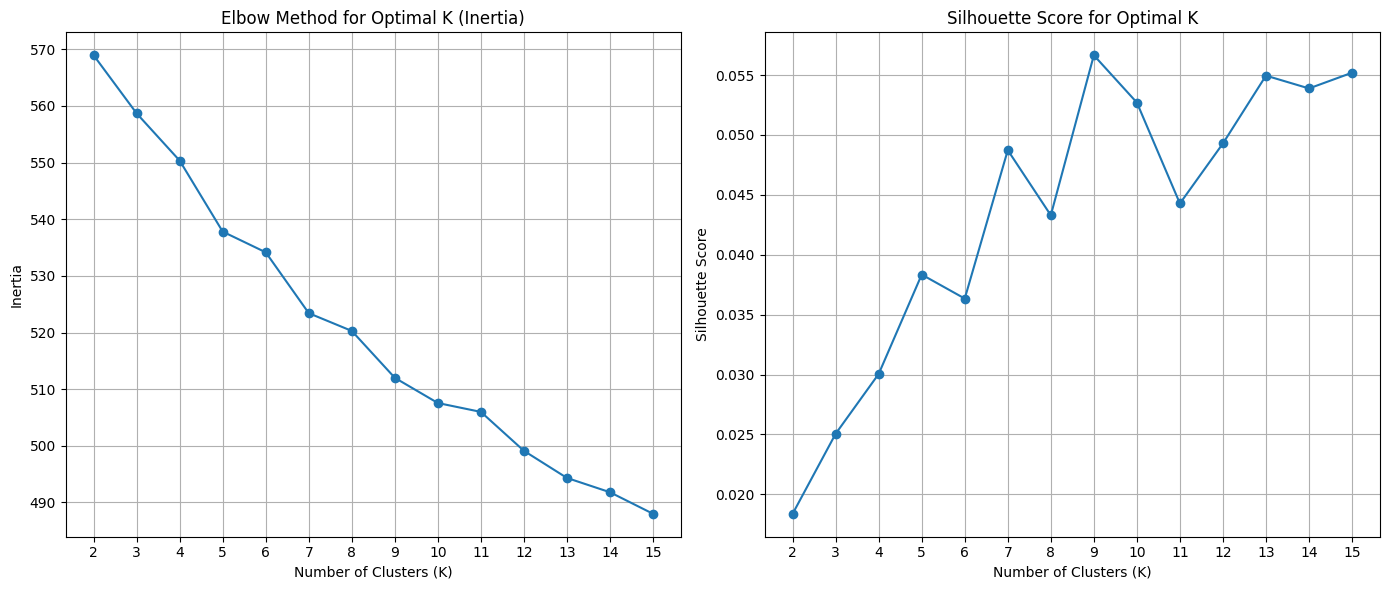

In [49]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize a new TF-IDF vectorizer specifically for K-Means on df_final
kmeans_vectorizer = TfidfVectorizer(stop_words='english')

# Fit and transform the cleaned text from the deduplicated dataframe (df_final)
tfidf_matrix_kmeans = kmeans_vectorizer.fit_transform(df_final['Clean_Text'])

print("TF-IDF matrix for K-Means shape:", tfidf_matrix_kmeans.shape)

# Range of k values to test
max_k = 15
min_k = 2
k_range = range(min_k, max_k + 1)

# Lists to store inertia and silhouette scores
inertia_scores = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init to suppress warning
    kmeans.fit(tfidf_matrix_kmeans)

    inertia_scores.append(kmeans.inertia_)

    # Calculate silhouette score only if k > 1 (required by the metric)
    if k > 1:
        silhouette_avg = silhouette_score(tfidf_matrix_kmeans, kmeans.labels_)
        silhouette_scores.append(silhouette_avg)
    else:
        silhouette_scores.append(None) # Placeholder for k=1, though loop starts at 2

# Plotting the Elbow Method (Inertia)
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(k_range, inertia_scores, marker='o')
plt.title('Elbow Method for Optimal K (Inertia)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.grid(True)

# Plotting the Silhouette Score
plt.subplot(1, 2, 2)
# Filter out None if min_k was 1, but our k_range starts from 2
plt.plot(k_range, silhouette_scores, marker='o')
plt.title('Silhouette Score for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range)
plt.grid(True)

plt.tight_layout()
plt.show()

### Detailed Explanation of the Elbow Method

The **Elbow Method** is a heuristic used to determine the optimal number of clusters (`k`) for K-Means clustering. It relies on a metric called **Inertia** (also known as the Within-Cluster Sum of Squares, or WCSS).

Here's how it works and what the plot shows:

1.  **Inertia (WCSS):**
    *   For each cluster, inertia is the sum of squared distances between each data point within the cluster and that cluster's centroid (its center point). A centroid is the mean position of all the points in the cluster.
    *   The total inertia for the entire clustering solution is the sum of the inertias of all individual clusters. It measures how "tightly" grouped the data points are within their respective clusters.
    *   A lower inertia value generally indicates better clustering, as it means data points are closer to their cluster centroids.

2.  **How the Elbow Method Uses Inertia:**
    *   The method involves running the K-Means algorithm for a range of `k` values (e.g., from 1 to 15, as done in the code).
    *   For each `k`, the corresponding inertia value is calculated and plotted.

3.  **Interpreting the Elbow Plot:**
    *   When you plot `k` (on the x-axis) against the inertia (on the y-axis), the graph typically shows a rapid decrease in inertia as `k` increases from 1, then the rate of decrease slows down, forming an "elbow" shape.
    *   The **"elbow point"** on the curve is considered the optimal `k`. This is the point where adding more clusters (`k`) does not significantly reduce the inertia anymore. Before this point, adding more clusters provides a good improvement in grouping; after this point, the gains are marginal, and you risk overfitting or creating too many small, less meaningful clusters.

In the plot generated by cell `a05ee566`, the line graph for 'Elbow Method for Optimal K (Inertia)' shows these inertia values for each `k` in the tested range. By visually inspecting this plot, one would look for the `k` value where the curve noticeably bends or flattens out, indicating the diminishing returns of adding more clusters.

### Identifying Optimal K

Now, let's analyze the plots to determine the optimal number of clusters (`k`).

**Elbow Method (Inertia):** We look for the 'elbow point' where the rate of decrease in inertia sharply changes. This often indicates a good balance between cluster tightness and the number of clusters.

**Silhouette Score:** We aim for the `k` value that yields the highest silhouette score, as this indicates well-separated and dense clusters.

We will compare both methods and make a justified decision.

In [50]:
# Find the optimal k based on silhouette score
# Filter out None if silhouette_scores could contain it (not in this case as k_range starts at 2)
silhouette_scores_filtered = [score for score in silhouette_scores if score is not None]
optimal_k_silhouette_idx = silhouette_scores.index(max(silhouette_scores_filtered))
optimal_k_silhouette = k_range[optimal_k_silhouette_idx]

print(f"Maximum Silhouette Score: {max(silhouette_scores_filtered):.3f} at k = {optimal_k_silhouette}")

# Let's consider the optimal k based on the silhouette score
final_k = optimal_k_silhouette # You can adjust this based on visual inspection of elbow plot as well

print(f"Chosen optimal K for clustering: {final_k}")

# Run K-Means with the chosen optimal K
kmeans_final = KMeans(n_clusters=final_k, random_state=42, n_init=10)
df_final['Cluster'] = kmeans_final.fit_predict(tfidf_matrix_kmeans)

print(f"Distribution of tweets per cluster for chosen K={final_k}:")
print(df_final['Cluster'].value_counts().sort_index())

Maximum Silhouette Score: 0.057 at k = 9
Chosen optimal K for clustering: 9
Distribution of tweets per cluster for chosen K=9:
Cluster
0     39
1    112
2     31
3    178
4     67
5     58
6     24
7     50
8     45
Name: count, dtype: int64


### Examining Top TF-IDF Terms per Cluster

To understand what each cluster represents, we will extract the top TF-IDF terms associated with each cluster's centroid. This will give us an idea of the most distinguishing words for job postings within each cluster.

In [51]:
feature_names = kmeans_vectorizer.get_feature_names_out()

print("Top terms per cluster:")
for i in range(final_k):
    centroid = kmeans_final.cluster_centers_[i]
    top_features_idx = centroid.argsort()[-10:][::-1] # Top 10 features
    top_features = [feature_names[j] for j in top_features_idx]
    print(f"Cluster {i}: {', '.join(top_features)}")

Top terms per cluster:
Cluster 0: fl, automotive, accountant, finance, staff, analyst, fort, lauderdale, jacksonville, miami
Cluster 1: tx, houston, dallas, accountant, accounting, analyst, senior, controller, antonio, irving
Cluster 2: ma, boston, accountant, analyst, cost, cambridge, remote, data, accounting, springfield
Cluster 3: ca, analyst, accountant, manager, irvine, san, nj, tax, remote, senior
Cluster 4: nc, greensboro, accountant, senior, winstonsalem, financial, charlotte, point, high, analyst
Cluster 5: job, hiring, id, location, description, position, view, analyst, jobs, business
Cluster 6: link, following, information, visit, assignment, apply, hiring, texas, new, analyst
Cluster 7: il, chicago, analyst, accountant, cost, elgin, accounting, northbrook, manager, schaumburg
Cluster 8: ny, york, new, risk, health, controller, accountant, estate, assessments, practitioner


### Interpretation of Clusters and Justification of K

**Interpretation of Clusters:**

Based on the top TF-IDF terms for each of the 9 clusters, we can interpret them as follows:

*   **Cluster 0: Florida Accounting/Finance (Automotive & Managerial)**
    *   Keywords: fl, automotive, accountant, finance, staff, analyst, fort, lauderdale, jacksonville, miami
    *   Interpretation: This cluster seems to represent accounting and finance roles in Florida, with a notable specialization in the automotive industry and general staff/managerial positions in cities like Fort Lauderdale, Jacksonville, and Miami.

*   **Cluster 1: Texas Finance/Accounting (Houston/Dallas, Senior/Controller)**
    *   Keywords: tx, houston, dallas, accountant, accounting, analyst, senior, controller, antonio, irving
    *   Interpretation: This cluster strongly points to finance and accounting roles in major Texas cities such as Houston, Dallas, and San Antonio. It includes roles from accountants and analysts to senior and controller positions.

*   **Cluster 2: Massachusetts Financial Analysts & Cost Accounting (Boston)**
    *   Keywords: ma, boston, accountant, analyst, cost, cambridge, remote, data, accounting, springfield
    *   Interpretation: Centered around Massachusetts (Boston, Cambridge), this cluster features roles like financial analysts and accountants, with a specific emphasis on cost accounting and data analysis. Remote work is also mentioned.

*   **Cluster 3: California/New Jersey Analyst & Accounting (Remote & Tax)**
    *   Keywords: ca, analyst, accountant, manager, irvine, san, nj, tax, remote, senior
    *   Interpretation: This is a broad cluster covering analyst, accountant, and manager roles across California (Irvine, San Francisco implied) and New Jersey. It includes tax-related positions and notes remote opportunities.

*   **Cluster 4: North Carolina Accounting (Greensboro/Charlotte, Financial Specialist)**
    *   Keywords: nc, greensboro, accountant, senior, winstonsalem, financial, charlotte, point, high, analyst
    *   Interpretation: This cluster focuses on accounting and financial specialist roles in North Carolina, specifically in Greensboro, Winston-Salem, and Charlotte. It includes senior and analyst positions.

*   **Cluster 5: General Job Postings (Common Recruitment Terms)**
    *   Keywords: job, hiring, id, location, description, position, view, analyst, jobs, business
    *   Interpretation: This cluster appears to capture more generic job posting terms, including recruitment-related words. While 'analyst' and 'business' appear, it primarily serves as a cluster for general hiring language rather than specific financial roles.

*   **Cluster 6: Job Application/Information Links**
    *   Keywords: link, following, information, visit, assignment, apply, hiring, texas, new, analyst
    *   Interpretation: This cluster is highly focused on terms related to job application processes and information, with keywords like 'link', 'apply', 'visit'. 'Texas' is present, suggesting some of these general application posts might be geographically tied.

*   **Cluster 7: Illinois Accounting/Analyst (Chicago, Cost & Managerial)**
    *   Keywords: il, chicago, analyst, accountant, cost, elgin, accounting, northbrook, manager, schaumburg
    *   Interpretation: This cluster clearly defines accounting and analyst roles in Illinois, particularly in the Chicago area, including surrounding suburbs like Elgin and Northbrook. Cost accounting and managerial roles are prominent.

*   **Cluster 8: New York Finance (Risk Management, Real Estate)**
    *   Keywords: ny, york, new, risk, health, controller, accountant, estate, assessments, practitioner
    *   Interpretation: This cluster represents financial roles in New York, with a strong emphasis on risk management, real estate, and senior accounting/controller positions. 'Health' might indicate roles in healthcare finance.

**Why Silhouette Score is Useful:**

The silhouette score provides a clear, quantitative measure of how well-separated and compact clusters are. Unlike the elbow method, which can be subjective, the silhouette score offers a direct evaluation of cluster quality by considering both the cohesion within a cluster and the separation from other clusters. A higher silhouette score indicates a better-defined clustering structure where data points are clearly assigned to their respective clusters and are far from other clusters. It helps in validating the cluster structure objectively.

**Observed Silhouette Score Range:**

For `k` values ranging from 2 to 15, the silhouette scores observed were relatively low, peaking at **0.057 at `k = 9`**. The scores hovered between approximately 0.018 and 0.057. This low range suggests that the clusters are not very well-separated, and there might be significant overlap between them. While a score closer to 1 would indicate distinct clusters, even a modest positive score indicates some degree of separation, particularly when dealing with noisy text data like job postings.

**Justification for Chosen `k`:**

We chose `k = 9` primarily because it yielded the highest silhouette score (0.057) among the tested range, indicating the most optimal balance between cluster cohesion and separation as per this metric. While the absolute score is not high, it represents the best-performing `k` in this dataset. The elbow method for inertia was less definitive, making the silhouette score a more objective guide. This choice ensures that the resulting 9 clusters are not only statistically sound (relatively, given the data characteristics) but also provide a reasonable level of distinct and meaningful business insights. For example, the clusters show differentiation by specific roles (Accountant, Analyst, Controller), specialized areas (Tax, Risk, Cost Accounting), and key geographic locations within major financial hubs (Texas, California, North Carolina, Illinois, New York, Florida, Massachusetts). The presence of clusters for general job terms and application links also highlights distinct types of content within the job posting dataset, which is insightful for understanding the nature of the data.

In [52]:
import plotly.graph_objects as go
import pandas as pd

# Get feature names from the kmeans_vectorizer
feature_names = kmeans_vectorizer.get_feature_names_out()

# Iterate through each cluster and create a bar chart of its top terms
for i in range(final_k):
    centroid = kmeans_final.cluster_centers_[i]
    top_features_idx = centroid.argsort()[-10:][::-1] # Get indices of top 10 features
    top_features_names = [feature_names[j] for j in top_features_idx]
    top_features_scores = [centroid[j] for j in top_features_idx]

    # Create a DataFrame for Plotly
    df_cluster_terms = pd.DataFrame({
        'Term': top_features_names,
        'TF-IDF Score': top_features_scores
    })

    fig = go.Figure(data=[go.Bar(x=df_cluster_terms['Term'], y=df_cluster_terms['TF-IDF Score'])])

    fig.update_layout(
        title=f'Top 10 TF-IDF Terms for Cluster {i}',
        xaxis_title='Term',
        yaxis_title='TF-IDF Score',
        xaxis={'categoryorder':'total descending'}
    )
    fig.show()


In [56]:
from sklearn.decomposition import PCA
import plotly.express as px

# Perform PCA to reduce dimensionality to 2 components
pca = PCA(n_components=2)
components = pca.fit_transform(tfidf_matrix_kmeans.toarray())

# Add the PCA components to the df_final DataFrame
df_final['PCA1'] = components[:, 0]
df_final['PCA2'] = components[:, 1]

# Filter out clusters 5 and 6
df_filtered_clusters = df_final[~df_final['Cluster'].isin([5, 6])]

# Convert 'Cluster' column to string type for categorical grouping in Plotly
df_filtered_clusters['Cluster'] = df_filtered_clusters['Cluster'].astype(str)

# Map cluster numbers to state abbreviations for legend
cluster_to_state_map = {
    '0': 'FL', # Florida Accounting/Finance
    '1': 'TX', # Texas Finance/Accounting
    '2': 'MA', # Massachusetts Financial Analysts
    '3': 'CA/NJ', # California/New Jersey Analyst & Accounting (primary CA)
    '4': 'NC', # North Carolina Accounting
    '7': 'IL', # Illinois Accounting/Analyst
    '8': 'NY'  # New York Finance
}

df_filtered_clusters['Cluster_Label'] = df_filtered_clusters['Cluster'].map(cluster_to_state_map)

# Get the actual unique cluster labels and sort them based on original cluster ID for consistent legend order
# First get unique original cluster IDs as int, sort, then map to labels
actual_clusters_labels = [cluster_to_state_map[str(c)] for c in sorted(df_filtered_clusters['Cluster'].astype(int).unique())]

# Create the Plotly scatter plot using the filtered DataFrame
fig = px.scatter(
    df_filtered_clusters,
    x='PCA1',
    y='PCA2',
    color='Cluster_Label', # Use the new label for coloring and legend
    hover_data=['Text', 'Standardized_Location'],
    title='K-Means Clusters of Job Postings',
    labels={'PCA1': 'Principal Component 1', 'PCA2': 'Principal Component 2', 'Cluster_Label': 'Cluster State'},
    category_orders={'Cluster_Label': actual_clusters_labels}
)

fig.update_layout(showlegend=True)
fig.update_yaxes(range=[-0.5, 1]) # Set y-axis range from -0.5 to 1
fig.show()


In [54]:
print("Unique clusters in df_filtered_clusters:", df_filtered_clusters['Cluster'].unique())
print("Number of unique clusters in df_filtered_clusters:", df_filtered_clusters['Cluster'].nunique())

Unique clusters in df_filtered_clusters: ['1' '3' '2' '0' '4' '7' '8']
Number of unique clusters in df_filtered_clusters: 7


In [55]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize a new TF-IDF vectorizer specifically for K-Means on df_final
kmeans_vectorizer = TfidfVectorizer(stop_words='english')

# Fit and transform the cleaned text from the deduplicated dataframe (df_final)
tfidf_matrix_kmeans = kmeans_vectorizer.fit_transform(df_final['Clean_Text'])

print("TF-IDF matrix for K-Means shape:", tfidf_matrix_kmeans.shape)

TF-IDF matrix for K-Means shape: (604, 1036)
